# 09 — Machine Learning Models
Trains and evaluates four regression models on the fully engineered `laptop_data_features.csv`.

**Models:** Ridge · Random Forest · Decision Tree · XGBoost  
**Metrics:** RMSE · MAE · R² · Average Percentage Difference  

> Run notebooks 01–08 first to produce `laptop_data_features.csv`.

In [1]:
!pip install xgboost scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 26.0 MB/s eta 0:00:04
   ----- ---------------------------------- 14.9/101.7 MB 49.1 MB/s eta 0:00:02
   --------- ------------------------------ 25.2/101.7 MB 49.7 MB/s eta 0:00:02
   -------------- ------------------------- 35.9/101.7 MB 50.0 MB/s eta 0:00:02
   ------------------ --------------------- 46.7/101.7 MB 50.4 MB/s eta 0:00:02
   ---------------------- ----------------- 57.4/101.7 MB 50.7 MB/s eta 0:00:01
   -------------------------- ------------- 67.9/101.7 MB 50.9 MB/s eta 0:00:01
   ------------------------------ --------- 78.1/101.7 MB 51.0 MB/s eta 0:00:01
   ---------------------------------- ----- 88.6/101.7 MB 51.1 MB/s eta 0:00:01
   -------------------------------------- - 99.1/101.7 MB 51.2 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 48.4 MB/s  0:00:02


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

## 1 — Load Data

In [3]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")
ld.info()

Shape: (1303, 42)
<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Inches                   1303 non-null   float64
 1   Ram                      1303 non-null   int64  
 2   Weight                   1303 non-null   float64
 3   Price                    1303 non-null   float64
 4   Company_TE               1303 non-null   float64
 5   Type_2 in 1 Convertible  1303 non-null   bool   
 6   Type_Gaming              1303 non-null   bool   
 7   Type_Netbook             1303 non-null   bool   
 8   Type_Notebook            1303 non-null   bool   
 9   Type_Ultrabook           1303 non-null   bool   
 10  Type_Workstation         1303 non-null   bool   
 11  Screen_Width             1303 non-null   int64  
 12  Screen_Height            1303 non-null   int64  
 13  Screen_PPI               1303 non-null   float64
 14  Screen_IsTouchscr

In [4]:
ld.head(3)

,Inches,Ram,Weight,Price,Company_TE,Type_2 in 1 Convertible,Type_Gaming,Type_Netbook,Type_Notebook,Type_Ultrabook,...,Mem_PrimaryType_TE,GPU_Brand_TE,GPU_TE,OS_Android,OS_Chrome OS,OS_Linux,OS_No OS,OS_Windows 10,OS_Windows 7,OS_macOS
0,13.3,8,1.37,71378.6832,83340.499886,False,False,False,False,True,...,70233.1087,53718.258994,67767.161692,False,False,False,False,False,False,True
1,13.3,8,1.34,47895.5232,83340.499886,False,False,False,False,True,...,27055.8864,53718.258994,58888.758674,False,False,False,False,False,False,True
2,15.6,8,1.86,30636.0000,56891.044222,False,False,False,True,False,...,70233.1087,53718.258994,60801.454172,False,False,False,True,False,False,False


In [5]:
# Confirm no remaining object columns
obj_cols = ld.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print("WARNING — object columns still present:", obj_cols)
else:
    print("All columns are numeric. Ready for ML.")

All columns are numeric. Ready for ML.


In [6]:
# Check nulls
null_counts = ld.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.any() else "No nulls.")

No nulls.


## 2 — Train / Test Split
Stratified split on price category so all price bands are represented equally in both sets.

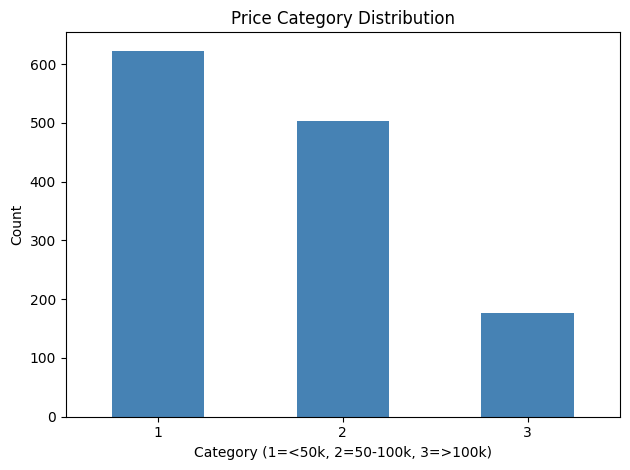

In [7]:
# Create price category for stratification (not used as a feature)
ld['_price_cat'] = pd.cut(
    ld['Price'],
    bins=[0, 50_000, 100_000, np.inf],
    labels=[1, 2, 3]
)

ld['_price_cat'].value_counts().sort_index().plot.bar(rot=0, color='steelblue')
plt.title("Price Category Distribution")
plt.xlabel("Category (1=<50k, 2=50-100k, 3=>100k)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(ld, ld['_price_cat']))

train_set = ld.iloc[train_idx].drop(columns=['_price_cat'])
test_set  = ld.iloc[test_idx].drop(columns=['_price_cat'])
ld.drop(columns=['_price_cat'], inplace=True)

print(f"Train: {train_set.shape}  |  Test: {test_set.shape}")

Train: (1042, 42)  |  Test: (261, 42)


In [9]:
X_train = train_set.drop(columns=['Price'])
y_train = train_set['Price'].copy()

X_test  = test_set.drop(columns=['Price'])
y_test  = test_set['Price'].copy()

print("Features:", X_train.shape[1])
print(X_train.columns.tolist())

Features: 41
['Inches', 'Ram', 'Weight', 'Company_TE', 'Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation', 'Screen_Width', 'Screen_Height', 'Screen_PPI', 'Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina', 'Screen_IsFullHD', 'Screen_Is4K', 'CPU_GHz', 'CPU_Brand_TE', 'CPU_Family_TE', 'CPU_TE', 'Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Flash_GB', 'Mem_eMMC_GB', 'Mem_Total_GB', 'Mem_HasSSD', 'Mem_IsCombo', 'Mem_IsSingleStorage', 'Mem_IsHybridStorage', 'Mem_PrimaryType_TE', 'GPU_Brand_TE', 'GPU_TE', 'OS_Android', 'OS_Chrome OS', 'OS_Linux', 'OS_No OS', 'OS_Windows 10', 'OS_Windows 7', 'OS_macOS']


## 3 — Evaluation Helper

In [10]:
def evaluate(name, y_true, y_pred):
    """Print RMSE, MAE, R² and Average Percentage Difference."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    apd  = np.mean(np.abs(y_true - y_pred) / ((y_true + y_pred) / 2) * 100)
    print(f"  {name}")
    print(f"    RMSE : {rmse:>10.2f}")
    print(f"    MAE  : {mae:>10.2f}")
    print(f"    R²   : {r2:>10.4f}")
    print(f"    APD  : {apd:>9.2f}%")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'APD': apd}

results = []

## 4 — Model 1: Ridge Regression
Linear baseline. GridSearchCV over `alpha` and `solver`.

In [11]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

ridge_params = {
    'ridge__alpha':  [0.01, 0.1, 1.0, 10.0, 100.0],
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

ridge_grid = GridSearchCV(
    ridge_pipeline, ridge_params,
    cv=10, scoring='neg_mean_squared_error', n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
print("Best params:", ridge_grid.best_params_)
print(f"Best CV RMSE: {np.sqrt(-ridge_grid.best_score_):.2f}")

Best params: {'ridge__alpha': 100.0, 'ridge__solver': 'lsqr'}
Best CV RMSE: 17416.33


In [12]:
ridge_preds = ridge_grid.predict(X_test)
results.append(evaluate("Ridge", y_test, ridge_preds))

  Ridge
    RMSE :   15942.76
    MAE  :   10821.50
    R²   :     0.8309
    APD  :     22.72%


## 5 — Model 2: Random Forest
Cross-validated baseline, then GridSearchCV for tuning.

In [13]:
# Quick cross-val check before grid search
rf_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestRegressor(n_estimators=100, random_state=42))
])
cv_scores = cross_val_score(
    rf_cv_pipeline, X_train, y_train,
    cv=10, scoring='neg_mean_squared_error', n_jobs=-1
)
rmse_cv = np.sqrt(-cv_scores)
print(f"CV RMSE  mean: {rmse_cv.mean():.2f}")
print(f"CV RMSE  std : {rmse_cv.std():.2f}")

CV RMSE  mean: 14239.55
CV RMSE  std : 3025.10


In [14]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestRegressor(random_state=42))
])

rf_params = {
    'rf__n_estimators':    [100, 200],
    'rf__max_depth':       [5, 10, None],
    'rf__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_params,
    cv=10, scoring='neg_mean_squared_error', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best params:", rf_grid.best_params_)
print(f"Best CV RMSE: {np.sqrt(-rf_grid.best_score_):.2f}")

Best params: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best CV RMSE: 14491.50


In [15]:
rf_preds = rf_grid.predict(X_test)
results.append(evaluate("Random Forest", y_test, rf_preds))

  Random Forest
    RMSE :   13750.38
    MAE  :    8516.40
    R²   :     0.8742
    APD  :     14.22%


## 6 — Model 3: Decision Tree

In [16]:
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt',     DecisionTreeRegressor(random_state=42))
])

dt_params = {
    'dt__max_depth':         [5, 10, 15, None],
    'dt__min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline, dt_params,
    cv=10, scoring='neg_mean_squared_error', n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print("Best params:", dt_grid.best_params_)
print(f"Best CV RMSE: {np.sqrt(-dt_grid.best_score_):.2f}")

Best params: {'dt__max_depth': None, 'dt__min_samples_split': 10}
Best CV RMSE: 18943.30


In [17]:
dt_preds = dt_grid.predict(X_test)
results.append(evaluate("Decision Tree", y_test, dt_preds))

  Decision Tree
    RMSE :   19310.70
    MAE  :   12169.51
    R²   :     0.7519
    APD  :     19.46%


## 7 — Model 4: XGBoost

In [18]:
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb',    XGBRegressor(random_state=42, verbosity=0))
])

xgb_params = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth':    [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_params,
    cv=10, scoring='neg_mean_squared_error', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("Best params:", xgb_grid.best_params_)
print(f"Best CV RMSE: {np.sqrt(-xgb_grid.best_score_):.2f}")

Best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 200}
Best CV RMSE: 13900.68


In [19]:
xgb_preds = xgb_grid.predict(X_test)
results.append(evaluate("XGBoost", y_test, xgb_preds))

  XGBoost
    RMSE :   13360.16
    MAE  :    8610.69
    R²   :     0.8812
    APD  :     14.03%


## 8 — Model Comparison

In [20]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('RMSE')
print(results_df.to_string())

                       RMSE           MAE        R2        APD
Model                                                         
XGBoost        13360.156128   8610.687949  0.881232  14.028300
Random Forest  13750.384814   8516.399995  0.874192  14.219066
Ridge          15942.758527  10821.502927  0.830877  22.724174
Decision Tree  19310.703545  12169.512218  0.751874  19.460842


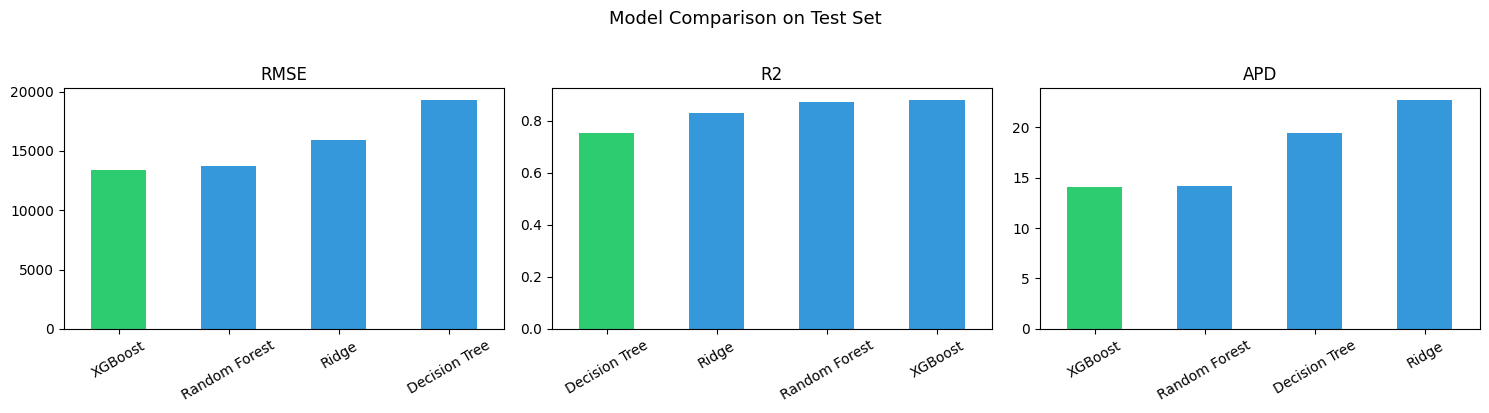

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['RMSE', 'R2', 'APD']):
    results_df[metric].sort_values().plot(
        kind='bar', ax=ax,
        color=['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
    )
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Model Comparison on Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9 — Actual vs Predicted

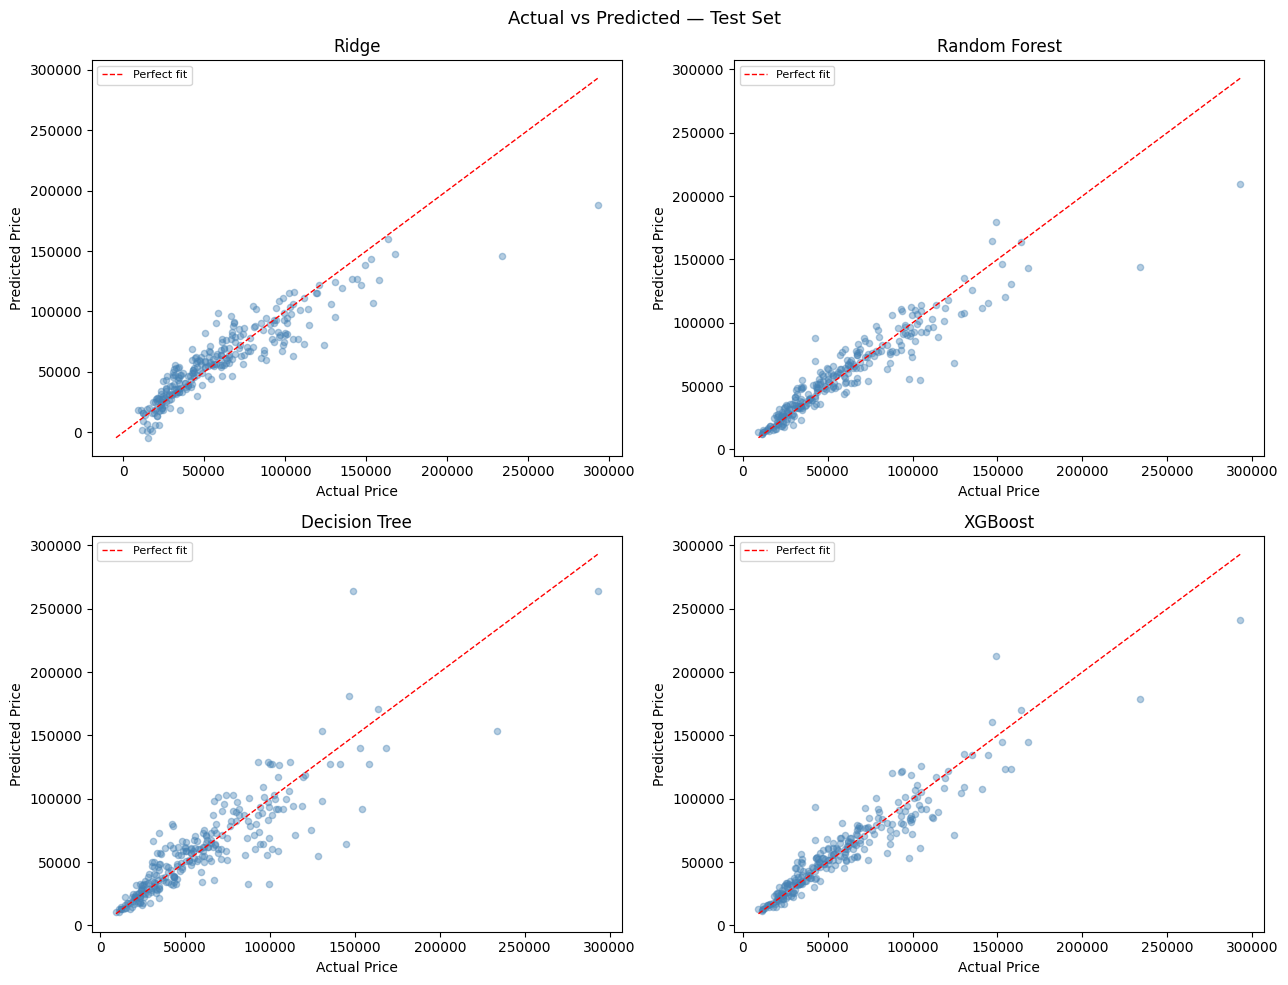

In [22]:
all_preds = {
    'Ridge':         ridge_preds,
    'Random Forest': rf_preds,
    'Decision Tree': dt_preds,
    'XGBoost':       xgb_preds
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (name, preds) in zip(axes.flat, all_preds.items()):
    ax.scatter(y_test, preds, alpha=0.4, color='steelblue', s=20)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Predicted — Test Set", fontsize=13)
plt.tight_layout()
plt.show()

## 10 — Feature Importance (Best Tree Model)

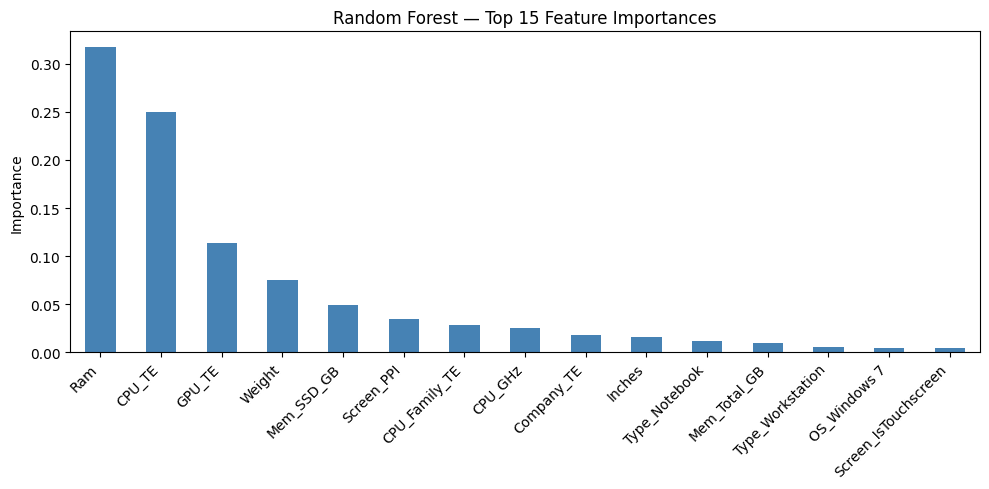

In [23]:
# Feature importance from Random Forest
rf_best = rf_grid.best_estimator_.named_steps['rf']
importance_rf = pd.Series(rf_best.feature_importances_, index=X_train.columns)
importance_rf = importance_rf.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance_rf.head(15).plot(kind='bar', color='steelblue')
plt.title("Random Forest — Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

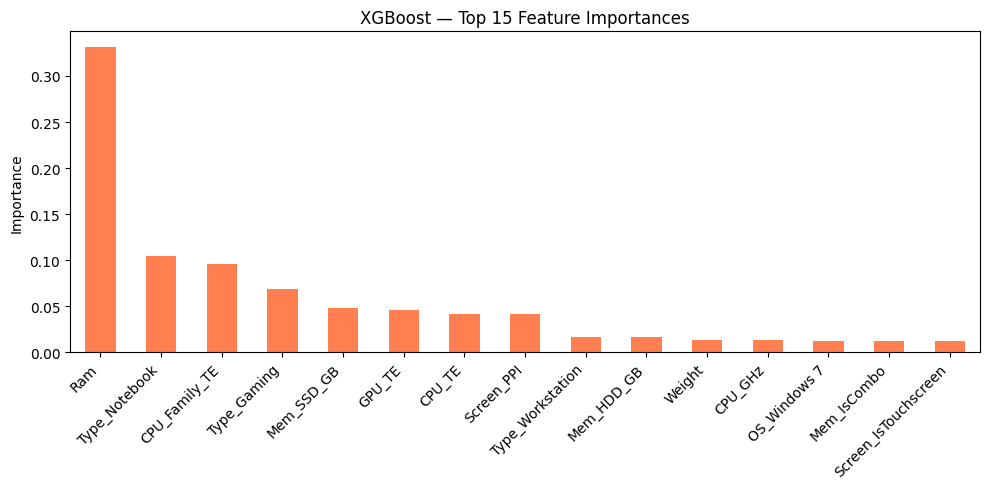

In [24]:
# Feature importance from XGBoost
xgb_best = xgb_grid.best_estimator_.named_steps['xgb']
importance_xgb = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
importance_xgb = importance_xgb.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance_xgb.head(15).plot(kind='bar', color='coral')
plt.title("XGBoost — Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()